# Bevölkerungsdichte in der Steiermark

Dieses Notebook erstellt publikationsreife Karten der Bevölkerung und Bevölkerungsdichte in der Steiermark. Grundlage sind das extrahierte 100-m-Bevölkerungsraster und die Gemeindegrenzen aus `Gemeindegrenzen.zip`.

## 1. Import Packages

In [1]:
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

## 2. Define Paths and Plot Settings

In [2]:
working_directory = Path.cwd().resolve()
PROJECT_DIR = next(
    path for path in (working_directory, *working_directory.parents)
    if (path / "OGD").is_dir() and (path / "FIG").is_dir()
)

OGD_DIR = PROJECT_DIR / "OGD"
FIG_DIR = PROJECT_DIR / "FIG" / "Population_Density"

POPULATION_PATH = OGD_DIR / "pd_popreg_100m_7767c33f-302c-11e3-beb4-0000c1ab0db6.geoparquet"
BOUNDARIES_ZIP = OGD_DIR / "Gemeindegrenzen.zip"
BOUNDARY_LAYER = "Gemeindegrenzen.shp"
BOUNDARY_COLUMNS = ["BEZNR6", "GEMNR", "GEMNAM"]

OUTPUT_PNG = FIG_DIR / "population_density_styria.png"
OUTPUT_PDF = FIG_DIR / "population_density_styria.pdf"
OUTPUT_MUNICIPALITY_PNG = FIG_DIR / "population_density_styria_municipalities.png"
OUTPUT_MUNICIPALITY_PDF = FIG_DIR / "population_density_styria_municipalities.pdf"

MAP_CRS = "EPSG:3035"
DPI = 600

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 9,
        "axes.linewidth": 0.6,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

## 3. Import Data

In [3]:
population = gpd.read_parquet(POPULATION_PATH)
municipalities = gpd.read_file(BOUNDARIES_ZIP)
print(f"Population grid cells: {len(population):,}")
print(f"Municipalities: {len(municipalities):,}")

Population grid cells: 588,603
Municipalities: 285


d:\CO2_Masterarbeit\CO2_Masterarbeit\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Value '12746,516106705474.000000000000' of field Gemeindegrenzen.FLAECHE_HA parsed incompletely to real 12746.
  return ogr_read(
d:\CO2_Masterarbeit\CO2_Masterarbeit\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Value '1557,8285611642518.000000000000' of field Gemeindegrenzen.FLAECHE_HA parsed incompletely to real 1557.
  return ogr_read(
d:\CO2_Masterarbeit\CO2_Masterarbeit\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Value '1986,7065126925297.000000000000' of field Gemeindegrenzen.FLAECHE_HA parsed incompletely to real 1986.
  return ogr_read(
d:\CO2_Masterarbeit\CO2_Masterarbeit\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Value '615,5113923390799.0000000000000' of field Gemeindegrenzen.FLAECHE_HA parsed incompletely to real 615.
  return ogr_read(
d:\CO2_Masterarbeit\CO2_Masterarbeit\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning:

## 4. Inspect Columns

In [4]:
display(population.head())
display(municipalities.head())

,population,cell_id,easting,northing,cell_size_m,geometry
0,3,AT_CRS3035RES100mN2604300E4650600,4650600,2604300,100,"POLYGON ((4650700 2604300, 4650700 2604400, 46..."
1,6,AT_CRS3035RES100mN2604400E4645100,4645100,2604400,100,"POLYGON ((4645200 2604400, 4645200 2604500, 46..."
2,4,AT_CRS3035RES100mN2604600E4654800,4654800,2604600,100,"POLYGON ((4654900 2604600, 4654900 2604700, 46..."
3,5,AT_CRS3035RES100mN2604800E4644600,4644600,2604800,100,"POLYGON ((4644700 2604800, 4644700 2604900, 46..."
4,2,AT_CRS3035RES100mN2604800E4645400,4645400,2604800,100,"POLYGON ((4645500 2604800, 4645500 2604900, 46..."


,BEZNR6,FLAECHE_HA,GEMNR6,GEMNR,GEMNAM,GEMNAM_KUR,geometry
0,601,12746.0,60101,0101,Graz,Graz,"POLYGON ((15.48864 47.02068, 15.48835 47.02054..."
1,603,1557.0,60305,0305,Frauental an der Laßnitz,Frauental,"POLYGON ((15.25905 46.78996, 15.25923 46.78975..."
2,603,1986.0,60318,0318,Lannach,Lannach,"POLYGON ((15.3027 46.95176, 15.30271 46.95177,..."
3,603,615.0,60323,0323,Pölfing-Brunn,Pölfing-Brunn,"POLYGON ((15.29894 46.71668, 15.29882 46.71675..."
4,603,1830.0,60324,0324,Preding,Preding,"POLYGON ((15.38687 46.85338, 15.38683 46.85341..."


## 5. Clean Up and Harmonize CRS

In [5]:
municipalities = municipalities.to_crs(MAP_CRS)

if population.crs is None:
    population = population.set_crs(MAP_CRS)
else:
    population = population.to_crs(MAP_CRS)

population["population"] = population["population"].astype(int)
population = population[population["population"] > 0].copy()

if hasattr(municipalities.geometry, "union_all"):
    styria_boundary = municipalities.geometry.union_all()
else:
    styria_boundary = municipalities.geometry.unary_union

styria_boundary_gs = gpd.GeoSeries([styria_boundary], crs=MAP_CRS)

print(f"Non-zero population cells: {len(population):,}")

Non-zero population cells: 588,603


## 6. Filter Population Grid to Styria

In [6]:
minx, miny, maxx, maxy = municipalities.total_bounds
population_styria = population.cx[minx:maxx, miny:maxy]
population_styria = gpd.clip(population_styria, styria_boundary)
population_styria = population_styria[population_styria["population"] > 0].copy()

if population_styria.empty:
    raise ValueError("No population cells intersect the Styria boundary. Check CRS and input files.")

display(population_styria["population"].describe())
print(f"Filtered Styria cells: {len(population_styria):,}")
print(f"Total population in mapped cells: {population_styria['population'].sum():,}")

count    123403.000000
mean         10.311565
std          20.483222
min           1.000000
25%           3.000000
50%           5.000000
75%          10.000000
max         584.000000
Name: population, dtype: float64

Filtered Styria cells: 123,403
Total population in mapped cells: 1,272,478


## 7. Helper Functions for Map Elements

In [7]:
def add_north_arrow(ax) -> None:
    ax.annotate(
        "N",
        xy=(0.94, 0.16),
        xytext=(0.94, 0.07),
        xycoords="axes fraction",
        ha="center",
        va="center",
        fontsize=9,
        arrowprops={"arrowstyle": "-|>", "linewidth": 1.1, "color": "black"},
    )


def reserve_lower_left_legend_space(ax, fraction: float = 0.30) -> None:
    minx, maxx = ax.get_xlim()
    ax.set_xlim(minx - (maxx - minx) * fraction, maxx)


def add_patch_legend(ax, colors, labels, title: str) -> None:
    handles = [Patch(facecolor=color, edgecolor="#4d4d4d", linewidth=0.3) for color in colors]
    legend = ax.legend(
        handles,
        labels,
        title=title,
        loc="lower left",
        bbox_to_anchor=(0.015, 0.025),
        frameon=False,
        borderpad=0.2,
        labelspacing=0.35,
        handlelength=1.0,
        handleheight=1.0,
        fontsize=7,
        title_fontsize=7,
    )
    return legend

## 8. Plot Population Heat Map

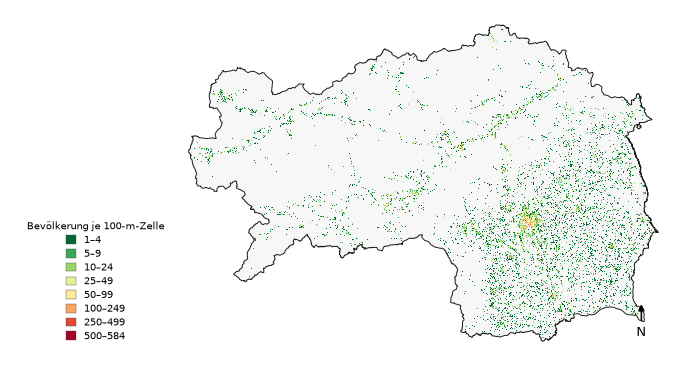

In [8]:
population_bin_edges = [0, 5, 10, 25, 50, 100, 250, 500, 1_000]
max_population = int(population_styria["population"].max())
if max_population >= population_bin_edges[-1]:
    population_bin_edges.append(max_population + 1)
else:
    population_bin_edges = [edge for edge in population_bin_edges if edge <= max_population]
    population_bin_edges = [0, *population_bin_edges[1:], max_population + 1]

n_population_bins = len(population_bin_edges) - 1
population_color_positions = (
    [0.0]
    if n_population_bins == 1
    else [i / (n_population_bins - 1) for i in range(n_population_bins)]
)
population_cmap = ListedColormap(
    plt.get_cmap("RdYlGn_r")(population_color_positions)
)
population_norm = BoundaryNorm(population_bin_edges, population_cmap.N)
population_bin_labels = []
for lower, upper in zip(population_bin_edges[:-1], population_bin_edges[1:]):
    if upper == max_population + 1 and lower >= 1_000:
        population_bin_labels.append(f"{lower:,}+".replace(",", "."))
    else:
        population_bin_labels.append(f"{max(1, lower):,}–{upper - 1:,}".replace(",", "."))
population_legend_colors = population_cmap.colors

fig, ax = plt.subplots(figsize=(6.8, 7.2), constrained_layout=True)
ax.set_facecolor("white")

municipalities.plot(ax=ax, facecolor="#f7f7f7", edgecolor="none", linewidth=0)

population_styria.plot(
    ax=ax,
    column="population",
    cmap=population_cmap,
    norm=population_norm,
    linewidth=0,
    rasterized=True,
)

municipalities.boundary.plot(ax=ax, color="#ffffff", linewidth=0.18, alpha=0.75)
styria_boundary_gs.boundary.plot(ax=ax, color="#1f1f1f", linewidth=0.7)

ax.set_axis_off()
ax.set_aspect("equal")

reserve_lower_left_legend_space(ax)
add_patch_legend(ax, population_legend_colors, population_bin_labels, "Bevölkerung je 100-m-Zelle")
add_north_arrow(ax)

plt.show()

## 9. Aggregate and Plot Municipality-Level Population Density

,GEMNR,GEMNAM,population_total,area_km2,population_density_km2
0,0101,Graz,305518,127.563674,2395.023518
198,2041,Knittelfeld,12844,13.860547,926.658985
195,2038,Zeltweg,6964,8.710454,799.499128
50,0669,Seiersberg-Pirka,12205,17.361812,702.979636
185,1766,Weiz,12117,17.486034,692.953012
16,0608,Feldkirchen bei Graz,7258,11.583911,626.558690
23,0624,Kalsdorf bei Graz,8993,15.168680,592.866351
17,0611,Gössendorf,4203,7.213597,582.649671
74,1053,Leibnitz,13422,23.547363,570.000127
21,0619,Hausmannstätten,3840,6.792902,565.295966


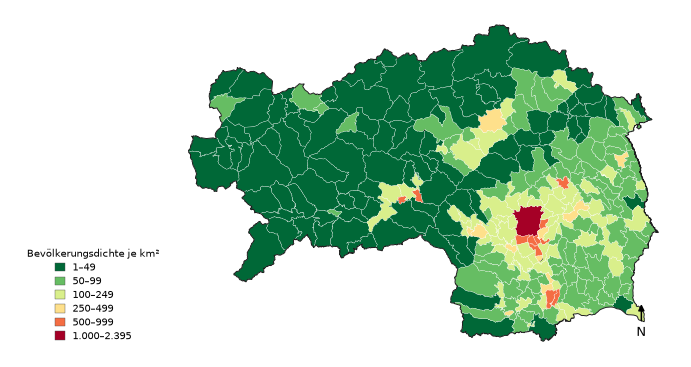

In [9]:
# Assign each 100 m grid cell to the municipality containing its centroid.
# This avoids double counting cells that were clipped at municipality borders.
population_points = population_styria.copy()
population_points["geometry"] = population_points.geometry.centroid

municipality_population = gpd.sjoin(
    population_points[["population", "geometry"]],
    municipalities[["GEMNR", "GEMNAM", "geometry"]],
    how="inner",
    predicate="within",
)

municipality_population = (
    municipality_population.groupby("GEMNR", as_index=False)["population"]
    .sum()
    .rename(columns={"population": "population_total"})
)

municipality_density = municipalities.merge(municipality_population, on="GEMNR", how="left")
municipality_density["population_total"] = municipality_density["population_total"].fillna(0).astype(int)
municipality_density["area_km2"] = municipality_density.geometry.area / 1_000_000
municipality_density["population_density_km2"] = (
    municipality_density["population_total"] / municipality_density["area_km2"]
)

display(
    municipality_density[
        ["GEMNR", "GEMNAM", "population_total", "area_km2", "population_density_km2"]
    ]
    .sort_values("population_density_km2", ascending=False)
    .head(10)
)

fig_muni, ax_muni = plt.subplots(figsize=(6.8, 7.2), constrained_layout=True)
ax_muni.set_facecolor("white")

density_values = municipality_density.loc[
    municipality_density["population_density_km2"] > 0, "population_density_km2"
]
if density_values.empty:
    raise ValueError("No positive municipality population densities were calculated.")

density_bin_edges = [0, 50, 100, 250, 500, 1_000, 2_500, 5_000]
max_density = float(density_values.max())
if max_density >= density_bin_edges[-1]:
    density_bin_edges.append(max_density + 1)
else:
    density_bin_edges = [edge for edge in density_bin_edges if edge <= max_density]
    density_bin_edges = [0, *density_bin_edges[1:], max_density + 1]

n_density_bins = len(density_bin_edges) - 1
density_color_positions = (
    [0.0]
    if n_density_bins == 1
    else [i / (n_density_bins - 1) for i in range(n_density_bins)]
)
density_cmap = ListedColormap(plt.get_cmap("RdYlGn_r")(density_color_positions))
density_norm = BoundaryNorm(density_bin_edges, density_cmap.N)

density_bin_labels = []
for lower, upper in zip(density_bin_edges[:-1], density_bin_edges[1:]):
    if upper == max_density + 1 and lower >= 5_000:
        density_bin_labels.append(f"{lower:,.0f}+".replace(",", "."))
    else:
        density_bin_labels.append(f"{max(1, lower):,.0f}–{upper - 1:,.0f}".replace(",", "."))
density_legend_colors = density_cmap.colors

municipality_density.plot(
    ax=ax_muni,
    column="population_density_km2",
    cmap=density_cmap,
    norm=density_norm,
    linewidth=0.18,
    edgecolor="#ffffff",
    missing_kwds={"color": "#f0f0f0", "edgecolor": "#ffffff"},
)

styria_boundary_gs.boundary.plot(ax=ax_muni, color="#1f1f1f", linewidth=0.7)

ax_muni.set_axis_off()
ax_muni.set_aspect("equal")

reserve_lower_left_legend_space(ax_muni)
add_patch_legend(ax_muni, density_legend_colors, density_bin_labels, "Bevölkerungsdichte je km²")
add_north_arrow(ax_muni)

plt.show()

## 10. Save Figures

In [10]:
FIG_DIR.mkdir(parents=True, exist_ok=True)

fig.savefig(OUTPUT_PNG, dpi=DPI, bbox_inches="tight", facecolor="white")
fig.savefig(OUTPUT_PDF, bbox_inches="tight", facecolor="white")
fig_muni.savefig(OUTPUT_MUNICIPALITY_PNG, dpi=DPI, bbox_inches="tight", facecolor="white")
fig_muni.savefig(OUTPUT_MUNICIPALITY_PDF, bbox_inches="tight", facecolor="white")

print(f"Saved PNG: {OUTPUT_PNG}")
print(f"Saved PDF: {OUTPUT_PDF}")
print(f"Saved municipality PNG: {OUTPUT_MUNICIPALITY_PNG}")
print(f"Saved municipality PDF: {OUTPUT_MUNICIPALITY_PDF}")

Saved PNG: D:\CO2_Masterarbeit\CO2_Masterarbeit\FIG\Population_Density\population_density_styria.png
Saved PDF: D:\CO2_Masterarbeit\CO2_Masterarbeit\FIG\Population_Density\population_density_styria.pdf
Saved municipality PNG: D:\CO2_Masterarbeit\CO2_Masterarbeit\FIG\Population_Density\population_density_styria_municipalities.png
Saved municipality PDF: D:\CO2_Masterarbeit\CO2_Masterarbeit\FIG\Population_Density\population_density_styria_municipalities.pdf


## 11. Optional Export of Filtered Data

In [11]:
FILTERED_OUTPUT = OGD_DIR / "population_grid_styria.geoparquet"
population_styria.to_parquet(FILTERED_OUTPUT, index=False)
print(f"Saved filtered Styria grid: {FILTERED_OUTPUT}")

Saved filtered Styria grid: D:\CO2_Masterarbeit\CO2_Masterarbeit\OGD\population_grid_styria.geoparquet
